# Reinforcement Learning Energy Management Project

This notebook is a Google Colab version of your reinforcement learning project based on the uploaded Python script. It uses the **Individual Household Electric Power Consumption** dataset packed inside `archive.zip` and builds a **Q-learning agent** to optimize energy cost in a simulated battery environment.

## What this notebook does
It:
- loads and preprocesses the household electricity dataset
- creates a simulated battery and electricity pricing environment
- trains a Q-learning agent
- compares the RL policy against a rule-based baseline
- plots reward, cost, battery behavior, and cost comparison

## Files required in Colab
Please upload:
- `archive.zip`

Then run the notebook cells from top to bottom.


## 0. Upload the Dataset in Google Colab

Before running the notebook, upload `archive.zip` into the Colab working directory.

In Colab, you can do this from the left **Files** panel or run the next cell.


In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive (1).zip


## 1. Imports and Core Functions

The following cell contains the full implementation from your uploaded Python script. It defines:
- dataset loading and preprocessing
- time-of-use pricing
- battery configuration
- environment design
- state discretization
- Q-learning agent
- training and evaluation functions


In [2]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import random

ZIP_PATH = "archive.zip"
TXT_NAME = "household_power_consumption.txt"

def load_power_data(zip_path: str, txt_name: str) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(txt_name) as f:
            df = pd.read_csv(f, sep=";", na_values="?", low_memory=False)
    return df

def preprocess_power_data(df: pd.DataFrame) -> pd.DataFrame:
    df["datetime"] = pd.to_datetime(
        df["Date"] + " " + df["Time"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    )
    numeric_cols = [
        "Global_active_power","Global_reactive_power","Voltage",
        "Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["datetime", "Global_active_power"]).copy()
    df = df.sort_values("datetime")
    hourly = (
        df.set_index("datetime")[["Global_active_power"]]
        .resample("1H").mean().dropna()
        .rename(columns={"Global_active_power": "demand_kw"})
    )
    hourly["hour"] = hourly.index.hour
    hourly["dayofweek"] = hourly.index.dayofweek
    hourly["month"] = hourly.index.month
    return hourly

def time_of_use_price(hour: int) -> float:
    if 0 <= hour < 6:
        return 0.10
    elif 6 <= hour < 17:
        return 0.18
    elif 17 <= hour < 22:
        return 0.30
    else:
        return 0.15

@dataclass
class BatteryConfig:
    capacity_kwh: float = 10.0
    max_charge_kw: float = 2.5
    max_discharge_kw: float = 2.5
    efficiency: float = 0.95
    degradation_penalty: float = 0.01

class EnergyEnv:
    def __init__(self, demand_df: pd.DataFrame, config: BatteryConfig):
        self.df = demand_df.reset_index(drop=False).copy()
        self.config = config
        self.ptr = 0
        self.battery_kwh = config.capacity_kwh / 2

    def reset(self, start_idx: int = 0):
        self.ptr = start_idx
        self.battery_kwh = self.config.capacity_kwh / 2
        return self._get_state()

    def _get_state(self):
        row = self.df.iloc[self.ptr]
        return {"hour": int(row["hour"]), "demand_kw": float(row["demand_kw"]), "battery_kwh": float(self.battery_kwh)}

    def step(self, action: int):
        row = self.df.iloc[self.ptr]
        demand_kw = float(row["demand_kw"])
        hour = int(row["hour"])
        price = time_of_use_price(hour)
        battery_before = self.battery_kwh
        grid_usage_kwh = demand_kw

        if action == 1:
            charge_amount = min(self.config.max_charge_kw, self.config.capacity_kwh - self.battery_kwh)
            self.battery_kwh += charge_amount * self.config.efficiency
            grid_usage_kwh = demand_kw + charge_amount
        elif action == 2:
            available_discharge = min(self.config.max_discharge_kw, self.battery_kwh)
            discharge_amount = min(available_discharge, demand_kw)
            self.battery_kwh -= discharge_amount
            grid_usage_kwh = max(0.0, demand_kw - discharge_amount)

        cost = grid_usage_kwh * price
        battery_change = abs(self.battery_kwh - battery_before)
        degradation_cost = battery_change * self.config.degradation_penalty
        total_cost = cost + degradation_cost
        reward = -total_cost

        self.ptr += 1
        done = self.ptr >= len(self.df) - 1
        next_state = self._get_state() if not done else None
        info = {"grid_usage_kwh": grid_usage_kwh, "price": price, "cost": cost,
                "degradation_cost": degradation_cost, "total_cost": total_cost,
                "battery_kwh": self.battery_kwh}
        return next_state, reward, done, info

class StateDiscretizer:
    def __init__(self, max_demand: float, capacity_kwh: float, demand_bins: int = 12, battery_bins: int = 10):
        self.max_demand = max_demand
        self.capacity_kwh = capacity_kwh
        self.demand_bins = demand_bins
        self.battery_bins = battery_bins

    def demand_bin(self, demand_kw: float) -> int:
        return min(self.demand_bins - 1, int((demand_kw / self.max_demand) * self.demand_bins))

    def battery_bin(self, battery_kwh: float) -> int:
        return min(self.battery_bins - 1, int((battery_kwh / self.capacity_kwh) * self.battery_bins))

    def transform(self, state: dict):
        return (int(state["hour"]), self.demand_bin(state["demand_kw"]), self.battery_bin(state["battery_kwh"]))

class QLearningAgent:
    def __init__(self, actions=3, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        self.q_table = {}
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

    def _ensure_state(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.actions)

    def choose_action(self, state):
        self._ensure_state(state)
        if random.random() < self.epsilon:
            return random.randint(0, self.actions - 1)
        return int(np.argmax(self.q_table[state]))

    def learn(self, state, action, reward, next_state, done):
        self._ensure_state(state)
        q_current = self.q_table[state][action]
        if done or next_state is None:
            q_target = reward
        else:
            self._ensure_state(next_state)
            q_target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] = q_current + self.alpha * (q_target - q_current)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

def train_agent(env, agent, discretizer, episodes=200, episode_length=24*7):
    rewards_history, cost_history = [], []
    max_start = len(env.df) - episode_length - 1
    for ep in range(episodes):
        start_idx = random.randint(0, max_start)
        state = env.reset(start_idx=start_idx)
        state_disc = discretizer.transform(state)
        total_reward, total_cost = 0.0, 0.0
        for _ in range(episode_length):
            action = agent.choose_action(state_disc)
            next_state, reward, done, info = env.step(action)
            total_reward += reward
            total_cost += info["total_cost"]
            next_disc = discretizer.transform(next_state) if next_state is not None else None
            agent.learn(state_disc, action, reward, next_disc, done)
            if done:
                break
            state_disc = next_disc
        agent.decay_epsilon()
        rewards_history.append(total_reward)
        cost_history.append(total_cost)
    return rewards_history, cost_history

def rule_based_policy(state: dict) -> int:
    hour = state["hour"]
    if 0 <= hour < 6:
        return 1
    elif 17 <= hour < 22:
        return 2
    return 0

def evaluate_policy(env, discretizer, agent=None, use_rule_based=False, start_idx=0, steps=24*7):
    state = env.reset(start_idx=start_idx)
    total_cost, total_reward = 0.0, 0.0
    traces = {"battery": [], "price": [], "demand": [], "action": [], "cost": []}
    for _ in range(steps):
        if use_rule_based:
            action = rule_based_policy(state)
        else:
            state_disc = discretizer.transform(state)
            agent._ensure_state(state_disc)
            action = int(np.argmax(agent.q_table[state_disc]))
        next_state, reward, done, info = env.step(action)
        total_reward += reward
        total_cost += info["total_cost"]
        traces["battery"].append(info["battery_kwh"])
        traces["price"].append(info["price"])
        traces["demand"].append(state["demand_kw"])
        traces["action"].append(action)
        traces["cost"].append(info["total_cost"])
        if done:
            break
        state = next_state
    return {"total_cost": total_cost, "total_reward": total_reward, **traces}



## 2. Load Dataset and Prepare the Environment

This section reads the uploaded dataset, preprocesses it into hourly demand values, initializes the battery environment, and creates the reinforcement learning agent.


In [3]:
raw_df = load_power_data(ZIP_PATH, TXT_NAME)
hourly_df = preprocess_power_data(raw_df)

print("Hourly data preview:")
print(hourly_df.head())
print("\nHourly dataset shape:", hourly_df.shape)

config = BatteryConfig()
env = EnergyEnv(hourly_df, config)
discretizer = StateDiscretizer(
    max_demand=float(hourly_df["demand_kw"].max()),
    capacity_kwh=config.capacity_kwh
)
agent = QLearningAgent()


Hourly data preview:
                     demand_kw  hour  dayofweek  month
datetime                                              
2006-12-16 17:00:00   4.222889    17          5     12
2006-12-16 18:00:00   3.632200    18          5     12
2006-12-16 19:00:00   3.400233    19          5     12
2006-12-16 20:00:00   3.268567    20          5     12
2006-12-16 21:00:00   3.056467    21          5     12

Hourly dataset shape: (34168, 4)


/tmp/ipykernel_240/2660572521.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean().dropna()


## 3. Train the Reinforcement Learning Agent

This cell trains the Q-learning agent over multiple episodes. The agent gradually learns how to reduce cost by charging and discharging the battery intelligently.


In [4]:
rewards_history, cost_history = train_agent(
    env,
    agent,
    discretizer,
    episodes=200,
    episode_length=24*7
)

print("Training complete.")


Training complete.


## 4. Evaluate the Learned Policy Against the Rule-Based Baseline

This section compares:
- the learned reinforcement learning policy
- a simple rule-based policy

The evaluation reports:
- RL total cost
- rule-based total cost
- cost savings


In [5]:
eval_start = 1000

rl = evaluate_policy(
    env,
    discretizer,
    agent=agent,
    use_rule_based=False,
    start_idx=eval_start
)

rb = evaluate_policy(
    env,
    discretizer,
    agent=agent,
    use_rule_based=True,
    start_idx=eval_start
)

print("RL total cost:", rl["total_cost"])
print("Rule-based total cost:", rb["total_cost"])
print("Cost savings:", rb["total_cost"] - rl["total_cost"])


RL total cost: 53.32603468361584
Rule-based total cost: 42.562537781728956
Cost savings: -10.763496901886882


## 5. Visualize Results

The following charts are generated:
1. Training reward per episode
2. Training cost per episode
3. Demand and battery behavior
4. Cost comparison between RL and rule-based strategies


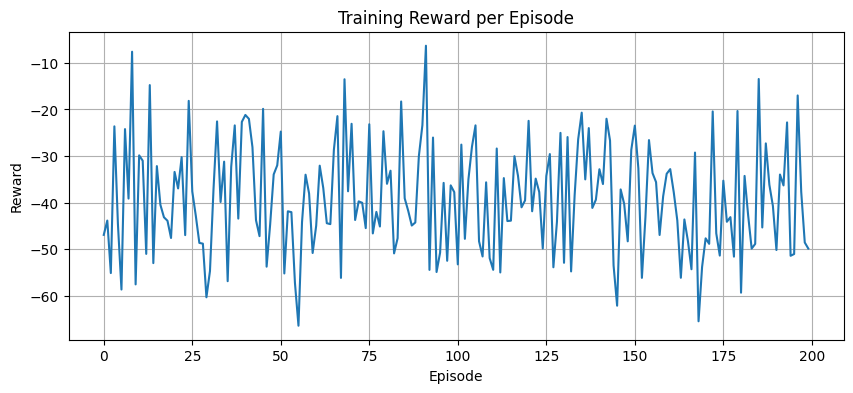

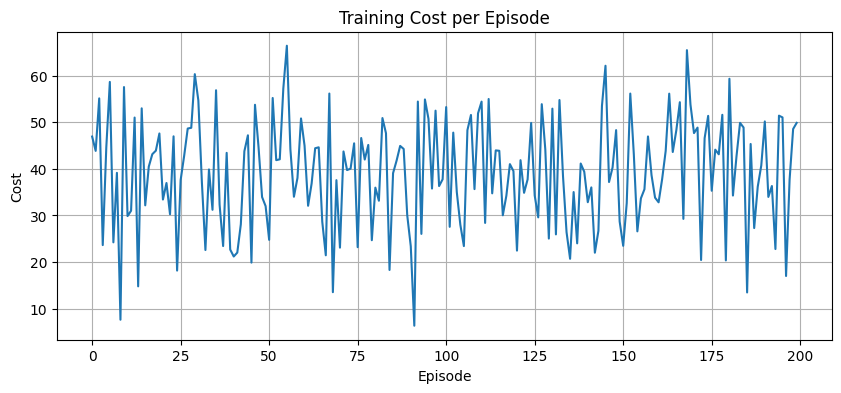

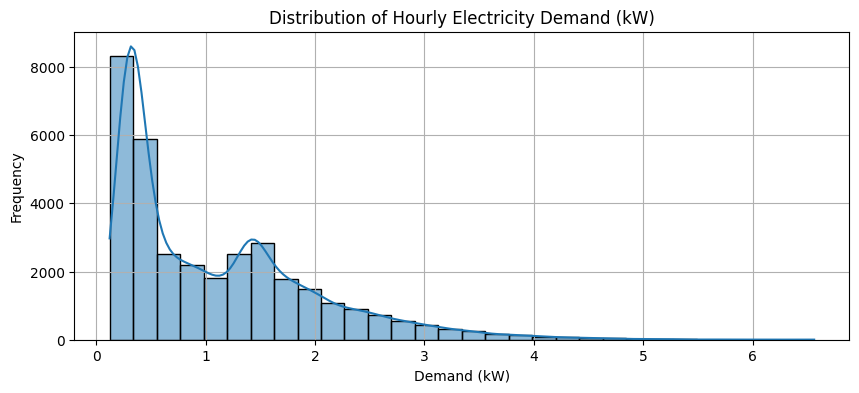

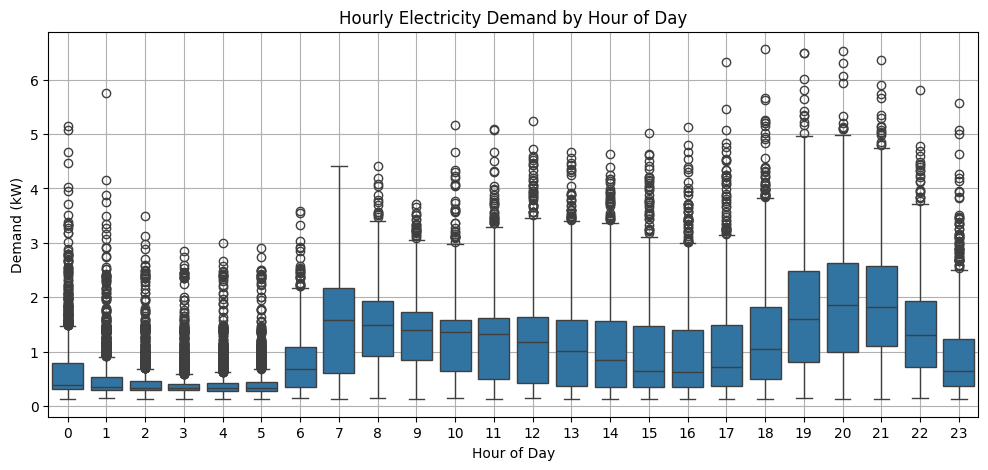

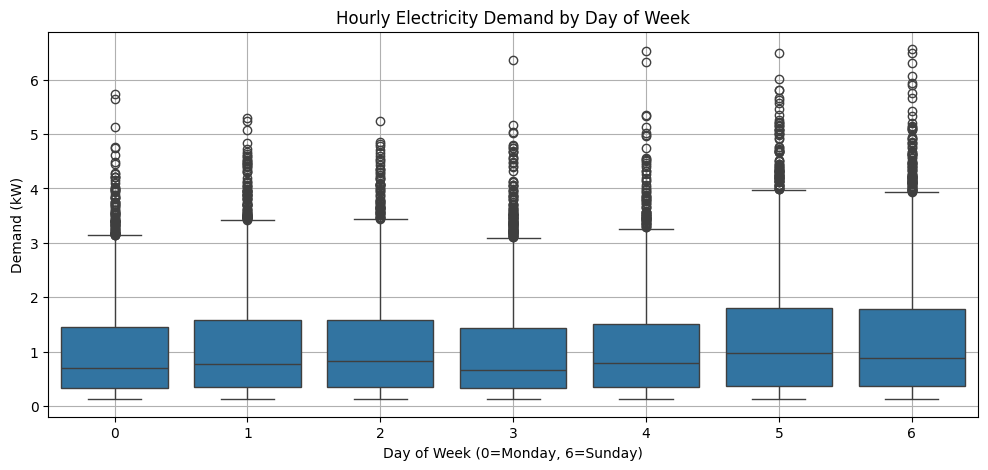

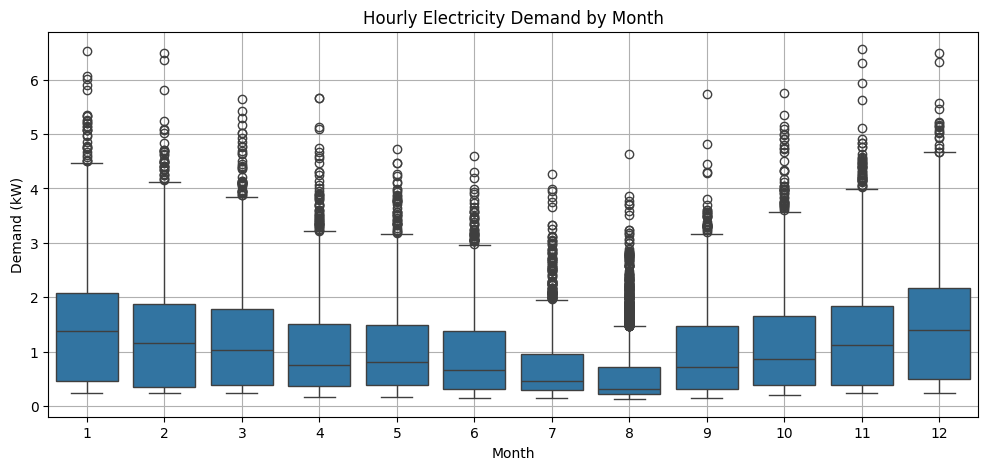

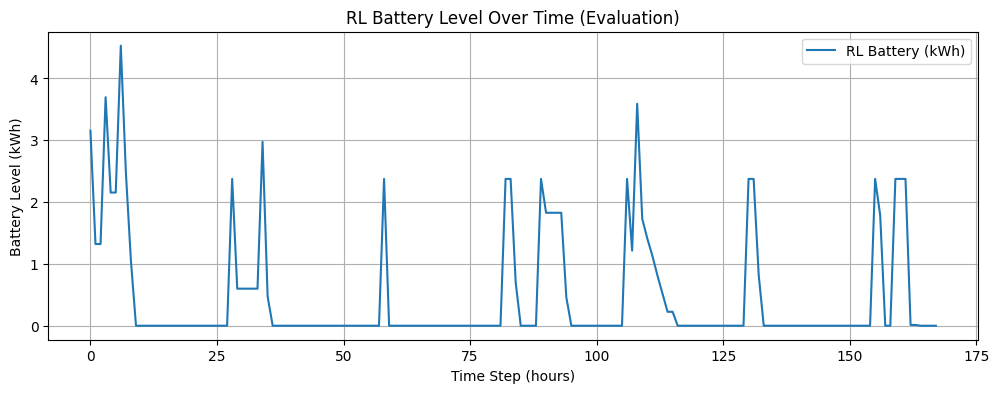

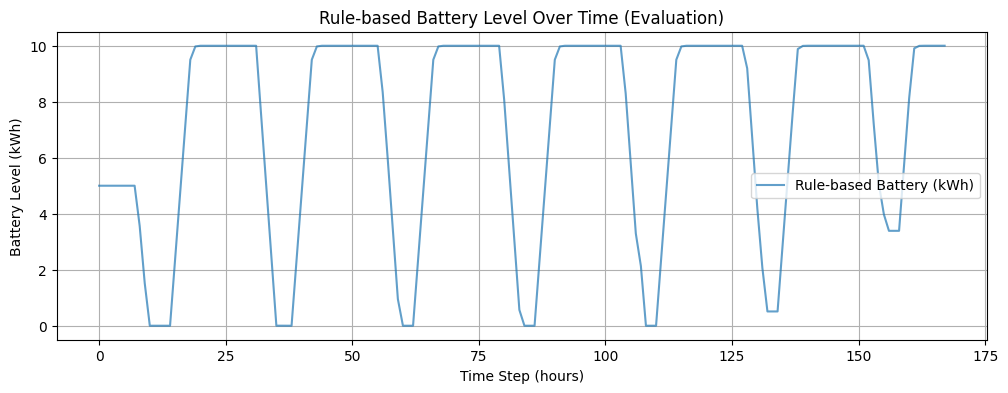

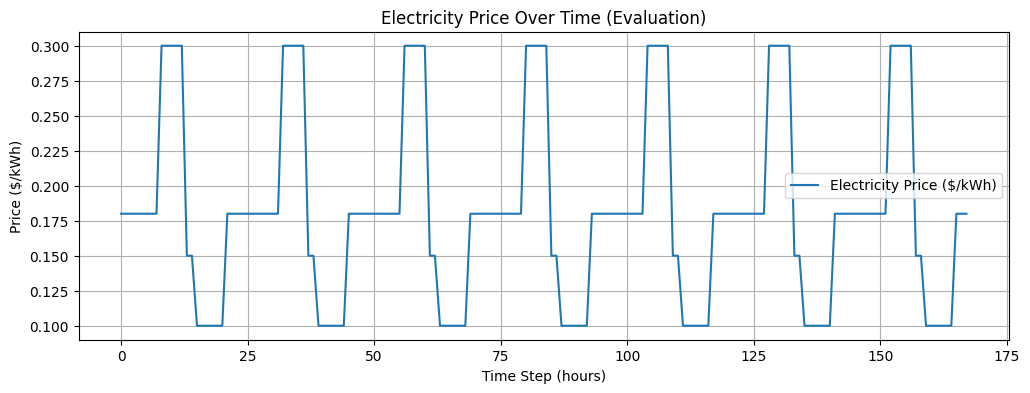

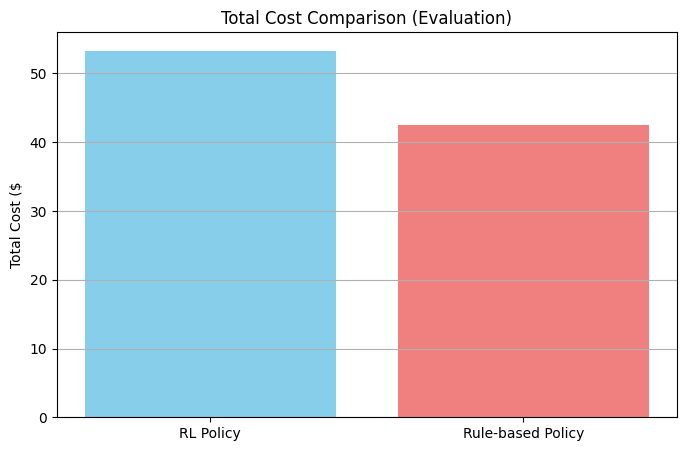

In [9]:
import seaborn as sns

# 1. Training Reward per Episode
plt.figure(figsize=(10, 4))
plt.plot(rewards_history)
plt.title("Training Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 2. Training Cost per Episode
plt.figure(figsize=(10, 4))
plt.plot(cost_history)
plt.title("Training Cost per Episode")
plt.xlabel("Episode")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

# 3. Distribution of Demand
plt.figure(figsize=(10, 4))
sns.histplot(hourly_df["demand_kw"], bins=30, kde=True)
plt.title("Distribution of Hourly Electricity Demand (kW)")
plt.xlabel("Demand (kW)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 4. Demand by Hour of Day
plt.figure(figsize=(12, 5))
sns.boxplot(x="hour", y="demand_kw", data=hourly_df)
plt.title("Hourly Electricity Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Demand (kW)")
plt.grid(True)
plt.show()

# 5. Demand by Day of Week
plt.figure(figsize=(12, 5))
sns.boxplot(x="dayofweek", y="demand_kw", data=hourly_df)
plt.title("Hourly Electricity Demand by Day of Week")
plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
plt.ylabel("Demand (kW)")
plt.grid(True)
plt.show()

# 6. Demand by Month
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="demand_kw", data=hourly_df)
plt.title("Hourly Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Demand (kW)")
plt.grid(True)
plt.show()

# 7. RL Battery Behavior during Evaluation
plt.figure(figsize=(12, 4))
plt.plot(rl["battery"], label="RL Battery (kWh)")
plt.title("RL Battery Level Over Time (Evaluation)")
plt.xlabel("Time Step (hours)")
plt.ylabel("Battery Level (kWh)")
plt.legend()
plt.grid(True)
plt.show()

# 8. Rule-based Battery Behavior during Evaluation
plt.figure(figsize=(12, 4))
plt.plot(rb["battery"], label="Rule-based Battery (kWh)", alpha=0.7)
plt.title("Rule-based Battery Level Over Time (Evaluation)")
plt.xlabel("Time Step (hours)")
plt.ylabel("Battery Level (kWh)")
plt.legend()
plt.grid(True)
plt.show()

# 9. Electricity Price Profile during Evaluation
plt.figure(figsize=(12, 4))
plt.plot(rl["price"], label="Electricity Price ($/kWh)")
plt.title("Electricity Price Over Time (Evaluation)")
plt.xlabel("Time Step (hours)")
plt.ylabel("Price ($/kWh)")
plt.legend()
plt.grid(True)
plt.show()

# 10. Cost Comparison between RL and Rule-based
plt.figure(figsize=(8, 5))
costs = [rl["total_cost"], rb["total_cost"]]
labels = ["RL Policy", "Rule-based Policy"]
plt.bar(labels, costs, color=['skyblue', 'lightcoral'])
plt.title("Total Cost Comparison (Evaluation)")
plt.ylabel("Total Cost ($")
plt.grid(axis='y')
plt.show()